# Análisis de la Satisfacción del Cliente en el Marketplace Olist

## Introducción

En este proyecto se realizará un Análisis Exploratorio de Datos (EDA) utilizando el dataset **Brazilian E-commerce Public Dataset by Olist** con el objetivo de comprender qué factores influyen en la satisfacción de los clientes dentro del marketplace.

A partir de la integración de diferentes tablas se analizarán pedidos, entregas, pagos, productos y reseñas para obtener información que permita explicar el comportamiento de las calificaciones otorgadas por los clientes.

## Objetivo

Analizar los principales factores asociados a la satisfacción del cliente, evaluando el impacto de los tiempos de entrega, el valor de las compras y otras variables relevantes del proceso de venta.

## Hipótesis

Se plantea que **los retrasos en la entrega tienen un mayor impacto en la satisfacción del cliente que el valor económico de la compra**, provocando una disminución en las calificaciones otorgadas cuando los pedidos son entregados fuera del plazo esperado.

Esta hipótesis será evaluada a lo largo del análisis mediante diferentes técnicas de exploración y visualización de datos.

## Carga de datos

En esta sección se cargarán los distintos conjuntos de datos que conforman el marketplace Olist. Cada tabla será analizada de forma individual para comprender su estructura, identificar las variables disponibles y determinar cómo se relaciona con el resto de la información antes de iniciar el proceso de integración y análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
customers_df = pd.read_csv('../data/raw/olist_customers_dataset.csv')
geolocation_df = pd.read_csv('../data/raw/olist_geolocation_dataset.csv')
order_items_df = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
order_payments_df = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('../data/raw/olist_orders_dataset.csv')
products_df = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers_df = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
product_category_name_translation_df = pd.read_csv('../data/raw/product_category_name_translation.csv')

## Comprensión de los datos

En esta etapa se realiza una primera exploración de cada uno de los datasets con el objetivo de comprender su estructura, identificar las variables disponibles y reconocer cómo se relacionan entre sí.

Para cada tabla se analizará su contenido, dimensiones y tipos de datos, estableciendo una base para las siguientes etapas de preparación e integración de la información.

### Customer

In [3]:
customers_df.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [5]:
customers_df.shape

(99441, 5)

### Geolocalitation

In [6]:
geolocation_df.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [7]:
geolocation_df.shape

(1000163, 5)

In [8]:
geolocation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


### Order Items

In [9]:
order_items_df.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [10]:
order_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [11]:
order_items_df.shape

(112650, 7)

### Order Payments

In [12]:
order_payments_df.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [13]:
order_payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [14]:
order_payments_df.shape

(103886, 5)

### Order Reviews

In [15]:
order_reviews_df.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [16]:
order_reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   review_id                100000 non-null  str  
 1   order_id                 100000 non-null  str  
 2   review_score             100000 non-null  int64
 3   review_comment_title     11715 non-null   str  
 4   review_comment_message   41753 non-null   str  
 5   review_creation_date     100000 non-null  str  
 6   review_answer_timestamp  100000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [17]:
order_reviews_df.shape

(100000, 7)

### Orders

In [18]:
orders_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [19]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [20]:
orders_df.shape

(99441, 8)

### Products

In [21]:
products_df.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [22]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [23]:
products_df.shape

(32951, 9)

### Sellers

In [24]:
sellers_df.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [25]:
sellers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [26]:
sellers_df.shape

(3095, 4)

### Product Category name traslation

In [27]:
product_category_name_translation_df.head(5)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [28]:
product_category_name_translation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [29]:
product_category_name_translation_df.shape

(71, 2)

## Evaluación de la calidad de los datos

En esta etapa se evalúa la calidad de los datos para identificar posibles problemas que puedan afectar el análisis posterior.

Se revisarán aspectos como valores faltantes, registros duplicados y la consistencia de los tipos de datos con el fin de definir las transformaciones necesarias antes de construir el dataset analítico.

### Customer

In [30]:
customers_df.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [31]:
customers_df.duplicated().sum()

np.int64(0)

In [32]:
customers_df["customer_id"].is_unique

True

In [33]:
customers_df["customer_state"].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

### Geolocation

In [34]:
geolocation_df.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [35]:
geolocation_df.duplicated().sum()

np.int64(261831)

In [36]:
geolocation_df["geolocation_state"].value_counts()

geolocation_state
SP    404268
MG    126336
RJ    121169
RS     61851
PR     57859
SC     38328
BA     36045
GO     20139
ES     16748
PE     16432
DF     12986
MT     12031
CE     11674
PA     10853
MS     10431
MA      7853
PB      5538
RN      5041
PI      4549
AL      4183
TO      3576
SE      3563
RO      3478
AM      2432
AC      1301
AP       853
RR       646
Name: count, dtype: int64

In [37]:
geolocation_df["geolocation_city"].value_counts()

geolocation_city
sao paulo                     135800
rio de janeiro                 62151
belo horizonte                 27805
são paulo                      24918
curitiba                       16593
                               ...  
são josé do herval                 1
almirante tamandaré do sul         1
são valentim                       1
três arroios                       1
ciríaco                            1
Name: count, Length: 8011, dtype: int64

### Order Items

In [38]:
order_items_df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [39]:
order_items_df.duplicated().sum()

np.int64(0)

In [40]:
order_items_df["order_id"].is_unique

False

In [41]:
order_items_df[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [42]:
order_items_df["order_item_id"].value_counts()

order_item_id
1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

### Order payments

In [43]:
order_payments_df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [44]:
order_payments_df.duplicated().sum()

np.int64(0)

In [45]:
order_payments_df["order_id"].is_unique

False

In [46]:
order_payments_df["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [47]:
order_payments_df[["payment_sequential", "payment_installments", "payment_value"]].describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


### Order Reviews

In [48]:
order_reviews_df.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       88285
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [49]:
(order_reviews_df.isnull().mean()*100).round(2)

review_id                   0.00
order_id                    0.00
review_score                0.00
review_comment_title       88.28
review_comment_message     58.25
review_creation_date        0.00
review_answer_timestamp     0.00
dtype: float64

In [50]:
order_reviews_df.duplicated().sum()

np.int64(0)

In [51]:
order_reviews_df["review_id"].is_unique

False

In [52]:
order_reviews_df["order_id"].is_unique

False

In [53]:
order_reviews_df["review_score"].value_counts()

review_score
5    57420
4    19200
1    11858
3     8287
2     3235
Name: count, dtype: int64

### Orders

In [54]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [55]:
(orders_df.isnull().mean()*100).round(2)

order_id                         0.00
customer_id                      0.00
order_status                     0.00
order_purchase_timestamp         0.00
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
order_estimated_delivery_date    0.00
dtype: float64

In [56]:
orders_df.duplicated().sum()

np.int64(0)

In [57]:
orders_df["order_id"].is_unique

True

In [58]:
orders_df["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### Products

In [59]:
products_df.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [60]:
(products_df.isnull().mean()*100).round(2)

product_id                    0.00
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

In [61]:
products_df.duplicated().sum()

np.int64(0)

In [62]:
products_df["product_id"].is_unique

True

In [63]:
products_df["product_category_name"].value_counts()

product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtype: int64

In [64]:
products_df[["product_name_lenght", "product_description_lenght", "product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]].describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


### Sellers

In [65]:
sellers_df.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [66]:
sellers_df.duplicated().sum()

np.int64(0)

In [67]:
sellers_df["seller_id"].is_unique

True

In [68]:
sellers_df["seller_city"].value_counts()

seller_city
sao paulo                 694
curitiba                  127
rio de janeiro             96
belo horizonte             68
ribeirao preto             52
                         ... 
aparecida de goiania        1
bandeirantes                1
vitoria de santo antao      1
palotina                    1
leme                        1
Name: count, Length: 611, dtype: int64

In [69]:
sellers_df["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

### Product Category name traslation

In [70]:
product_category_name_translation_df.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [71]:
product_category_name_translation_df.duplicated().sum()

np.int64(0)

In [72]:
product_category_name_translation_df["product_category_name"].value_counts()

product_category_name
beleza_saude                     1
informatica_acessorios           1
automotivo                       1
cama_mesa_banho                  1
moveis_decoracao                 1
                                ..
flores                           1
artes_e_artesanato               1
fraldas_higiene                  1
fashion_roupa_infanto_juvenil    1
seguros_e_servicos               1
Name: count, Length: 71, dtype: int64

In [73]:
product_category_name_translation_df["product_category_name_english"].value_counts()

product_category_name_english
health_beauty                1
computers_accessories        1
auto                         1
bed_bath_table               1
furniture_decor              1
                            ..
flowers                      1
arts_and_craftmanship        1
diapers_and_hygiene          1
fashion_childrens_clothes    1
security_and_services        1
Name: count, Length: 71, dtype: int64

### Observaciones

El análisis de calidad permitió comprender el estado general de los datasets e identificar los principales aspectos que deberán considerarse durante la preparación de los datos.

En términos generales, la información presenta un buen nivel de calidad. La mayoría de las tablas no contienen valores faltantes ni registros duplicados, mientras que los problemas detectados se concentran principalmente en columnas específicas, como fechas almacenadas en formato texto y algunos valores nulos que responden al contexto propio del negocio.

Además, se observó que no todas las variables disponibles serán necesarias para el análisis. Por este motivo, la siguiente etapa estará enfocada en seleccionar únicamente la información relevante e integrar los distintos datasets para construir un conjunto de datos analítico orientado a la hipótesis del proyecto.

## Preparación de datos

Luego de evaluar la estructura y la calidad de los datos, se definieron las variables que formarán parte del análisis en función de la hipótesis planteada.

Debido a que la información del marketplace Olist se encuentra distribuida en múltiples tablas relacionadas, será necesario integrarlas mediante sus claves de relación para construir un único dataset analítico. Este proceso permitirá reunir en una sola estructura la información de clientes, pedidos, productos, pagos y reseñas, facilitando el estudio de los factores que pueden influir en la satisfacción del cliente.

### Selección de variables

Durante la exploración inicial se identificó que algunos datasets incluyen atributos descriptivos que no aportan información relevante para responder la hipótesis del proyecto, como las dimensiones físicas de los productos, la cantidad de fotografías o la longitud de sus descripciones.

Por este motivo, se seleccionaron únicamente aquellas variables vinculadas al proceso de compra, la entrega del pedido, el valor de la transacción, la ubicación de clientes y vendedores, y la calificación otorgada por el cliente. Esta decisión permitirá construir un dataset más compacto, reducir información innecesaria y centrar el análisis en las variables con mayor impacto sobre el problema de negocio.

### Definición del dataset analítico

El modelo de datos de Olist distribuye la información de cada compra en diferentes tablas relacionadas entre sí. Las tablas **Orders** y **Order Items** constituyen el núcleo del modelo, ya que permiten vincular la información de clientes, productos, vendedores, pagos y reseñas mediante sus identificadores.

A partir de esta estructura relacional se definieron las variables que integrarán el dataset analítico, el cual servirá como base para las etapas de limpieza, creación de nuevas variables y análisis exploratorio orientado a validar la hipótesis del proyecto.

| Dataset            | Variables seleccionadas                                                                                                                                                                      | Justificación                                                                                                                                              |
| ------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Customers**      | `customer_id`, `customer_state`, `customer_city`                                                                                                                                             | Permiten identificar la ubicación del cliente y analizar si existen diferencias en la satisfacción según la región donde se realizó la compra.             |
| **Orders**         | `order_id`, `customer_id`, `order_status`, `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date` | Contiene la información principal del pedido y las fechas necesarias para calcular los tiempos de entrega y detectar posibles demoras.                     |
| **Order Items**    | `order_id`, `product_id`, `seller_id`, `price`, `freight_value`                                                                                                                              | Permite conocer el valor de los productos y del envío, variables que podrían influir en la percepción del cliente sobre la compra.                         |
| **Order Payments** | `order_id`, `payment_type`, `payment_installments`, `payment_value`                                                                                                                          | Incorpora información económica de cada pedido para evaluar si el monto abonado o la forma de pago presentan alguna relación con la calificación recibida. |
| **Order Reviews**  | `order_id`, `review_score`                                                                                                                                                                   | Contiene la calificación realizada por el cliente y constituye la variable principal sobre la que se desarrollará el análisis.                             |
| **Products**       | `product_id`, `product_category_name`                                                                                                                                                        | Permite analizar si determinadas categorías de productos presentan comportamientos diferentes respecto a la satisfacción del cliente.                      |
| **Sellers**        | `seller_id`, `seller_state`                                                                                                                                                                  | Incorpora la ubicación del vendedor, información que podrá utilizarse para estudiar diferencias regionales o ampliar el análisis en futuras etapas.        |


## Integración de conjuntos de datos

Una vez definidas las variables que formarán parte del análisis, se procederá a integrar los diferentes datasets mediante sus claves de relación.

El objetivo es construir un único dataset analítico que concentre la información relevante de clientes, pedidos, productos, pagos y reseñas, manteniendo la integridad de los datos y preservando la mayor cantidad posible de registros.

In [74]:
analysis_df = orders_df.copy()

In [75]:
analysis_df = analysis_df.merge(
    customers_df[ [
        "customer_id",
        "customer_state",
        "customer_city"] ], 
        on="customer_id", how="left")

In [76]:
analysis_df.shape

(99441, 10)

In [77]:
analysis_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,SP,santo andre


### Tratamiento de múltiples reseñas por pedido

Durante la integración de los datos se identificó que algunos pedidos presentaban más de una reseña asociada al mismo order_id. Para garantizar una única observación por pedido, primero se convirtió la columna review_answer_timestamp al tipo datetime y luego se conservó únicamente la última reseña registrada para cada orden, utilizando la fecha de respuesta como criterio de selección.

In [78]:
ordenes_duplicadas = order_reviews_df.loc[ order_reviews_df["order_id"].duplicated(),"order_id"].unique()

order_reviews_df[order_reviews_df["order_id"]==ordenes_duplicadas[0]]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
1035,afd9b3d196f0acd81d79d8ccd79c2430,5040757d4e06a4be96d3827b860b4e7c,5,NaN,NaN,2017-10-31 00:00:00,2017-11-04 21:12:29
1128,46abf3ea0b2710ad41390fdb79c32d84,5040757d4e06a4be96d3827b860b4e7c,5,NaN,NaN,2017-11-07 00:00:00,2017-11-10 20:07:48


In [79]:
order_reviews_df.groupby("order_id")["review_score"].nunique().value_counts()

review_score
1    99232
2      209
Name: count, dtype: int64

In [80]:
order_reviews_df["review_answer_timestamp"] = pd.to_datetime(order_reviews_df["review_answer_timestamp"], format='%Y-%m-%d %H:%M:%S')

In [81]:
reviews_summary = (
    order_reviews_df
    .sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")
)

In [82]:
analysis_df = analysis_df.merge(
    reviews_summary[ [
        "order_id", 
        "review_score"] ], 
        on="order_id", how="left")

In [83]:
analysis_df.shape

(99441, 11)

In [84]:
analysis_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,SP,sao paulo,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,BA,barreiras,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,GO,vianopolis,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,RN,sao goncalo do amarante,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,SP,santo andre,5


### Analisis

Analizar la tabla ordenes ya que se encuentran mas filas lo que indica que indica una relacion 1 a muchos 

In [85]:
orders_per_item = order_items_df["order_id"].value_counts().sort_values(ascending=False)

In [86]:
orders_per_item.head(5)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
428a2f660dc84138d969ccd69a0ab6d5    15
9ef13efd6949e4573a18964dd1bbe7f5    15
Name: count, dtype: int64

In [87]:
cantidad = (orders_per_item > 1 ).sum()

total= orders_per_item.shape[0]

print(f"Total de órdenes: { (total)}")
print(f"Total de órdenes con múltiples items: { (cantidad)}")
print(f"Porcentaje: {(cantidad/total):.2%}")

Total de órdenes: 98666
Total de órdenes con múltiples items: 9803
Porcentaje: 9.94%


In [88]:
order_per_payments = order_payments_df["order_id"].value_counts().sort_values(ascending=False)

In [89]:
order_per_payments.head(5)

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
ee9ca989fc93ba09a6eddc250ce01742    19
Name: count, dtype: int64

In [90]:
cantidad = (order_per_payments > 1).sum()

total = order_per_payments.shape[0]

print(f"Total de órdenes: { (total)}")
print(f"Total de órdenes con múltiples payments: { (cantidad)}")
print(f"Porcentaje: {(cantidad/total):.2%}")

Total de órdenes: 99440
Total de órdenes con múltiples payments: 2961
Porcentaje: 2.98%


### Agregación de tablas con relaciones uno a muchos

Durante la exploración de los datos se identificó que las tablas **Order Items** y **Order Payments** presentan una relación de uno a muchos respecto a la tabla **Orders**. Esto significa que un mismo pedido puede contener varios productos o registrarse mediante múltiples transacciones de pago.

Para evitar la duplicación de registros durante la integración de los datos, ambas tablas serán agregadas a nivel de pedido. De esta forma, cada orden estará representada por una única fila, preservando la consistencia del dataset analítico y facilitando el análisis posterior.

In [91]:
order_items_summary = (order_items_df.groupby("order_id")
                       .agg(total_items=("order_item_id", "count"), 
                            total_price=("price", "sum"), 
                            total_freight=("freight_value", "sum"), 
                            unique_products=("product_id", "nunique"), 
                            unique_sellers=("seller_id", "nunique") ) .reset_index() )

order_items_summary.head(5)

,order_id,total_items,total_price,total_freight,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1


In [92]:
order_payments_summary = (order_payments_df.groupby("order_id")
                          .agg(payments_count=("payment_sequential", "count"), 
                               total_payment=("payment_value", "sum"), 
                               max_installments =("payment_installments", "max") ) .reset_index() )

order_payments_summary.head(5)

,order_id,payments_count,total_payment,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,1,259.83,3
2,000229ec398224ef6ca0657da4fc703e,1,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,1,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.04,3


In [93]:
analysis_df = analysis_df.merge(
    order_items_summary, 
    on="order_id", how="left" )

In [94]:
analysis_df = analysis_df.merge(
    order_payments_summary, 
    on="order_id", how="left" )

In [95]:
analysis_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,review_score,total_items,total_price,total_freight,unique_products,unique_sellers,payments_count,total_payment,max_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,SP,sao paulo,4,1.0,29.99,8.72,1.0,1.0,3.0,38.71,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,BA,barreiras,4,1.0,118.70,22.76,1.0,1.0,1.0,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,GO,vianopolis,5,1.0,159.90,19.22,1.0,1.0,1.0,179.12,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,RN,sao goncalo do amarante,5,1.0,45.00,27.20,1.0,1.0,1.0,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,SP,santo andre,5,1.0,19.90,8.72,1.0,1.0,1.0,28.62,1.0


In [96]:
analysis_df.shape

(99441, 19)

In [97]:
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  str    
 1   customer_id                    99441 non-null  str    
 2   order_status                   99441 non-null  str    
 3   order_purchase_timestamp       99441 non-null  str    
 4   order_approved_at              99281 non-null  str    
 5   order_delivered_carrier_date   97658 non-null  str    
 6   order_delivered_customer_date  96476 non-null  str    
 7   order_estimated_delivery_date  99441 non-null  str    
 8   customer_state                 99441 non-null  str    
 9   customer_city                  99441 non-null  str    
 10  review_score                   99441 non-null  int64  
 11  total_items                    98666 non-null  float64
 12  total_price                    98666 non-null  float64
 1

In [98]:
analysis_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_state                      0
customer_city                       0
review_score                        0
total_items                       775
total_price                       775
total_freight                     775
unique_products                   775
unique_sellers                    775
payments_count                      1
total_payment                       1
max_installments                    1
dtype: int64

In [99]:
analysis_df.duplicated().sum()

np.int64(0)

In [100]:
analysis_df.loc[ analysis_df["total_items"].isna(), ["order_id", "order_status"] ].head(20)

,order_id,order_status
266,8e24261a7e58791d10cb1bf9da94df5c,unavailable
586,c272bcd21c287498b4883c7512019702,unavailable
687,37553832a3a89c9b2db59701c357ca67,unavailable
737,d57e15fb07fd180f06ab3926b39edcd2,unavailable
1130,00b1cb0320190ca0daa2c88b35206009,canceled
1160,2f634e2cebf8c0283e7ef0989f77d217,unavailable
1579,ee0db22a8e742b752914016708470ec8,unavailable
1801,ed3efbd3a87bea76c2812c66a0b32219,canceled
1826,6ad57aecbae806a7e9cc2cdb6b380711,unavailable
1868,df8282afe61008dc26c6c31011474d02,canceled


In [101]:
analysis_df["order_id"].duplicated().sum()

np.int64(0)

### Transformamos el tipo de datos

In [102]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    analysis_df[col] = pd.to_datetime(analysis_df[col], format='%Y-%m-%d %H:%M:%S')

In [103]:
analysis_df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_state                              str
customer_city                               str
review_score                              int64
total_items                             float64
total_price                             float64
total_freight                           float64
unique_products                         float64
unique_sellers                          float64
payments_count                          float64
total_payment                           float64
max_installments                        float64
dtype: object

## Feature Engineering

Con el dataset analítico ya integrado y validado, se generarán nuevas variables derivadas de las fechas del proceso de compra y entrega.

Estas variables permitirán medir tiempos, identificar retrasos y facilitar el análisis de su posible relación con la calificación otorgada por los clientes.

In [104]:
analysis_df["delivery_time_days"] = (
    analysis_df["order_delivered_customer_date"]
    - analysis_df["order_purchase_timestamp"]
).dt.days

In [105]:
analysis_df["approval_time_hours"] = (
    analysis_df["order_approved_at"]
    - analysis_df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

In [106]:
analysis_df["estimated_delivery_days"] = (
    analysis_df["order_estimated_delivery_date"]
    - analysis_df["order_purchase_timestamp"]
).dt.days

In [107]:
analysis_df["delivery_delay_days"] = (
    analysis_df["order_delivered_customer_date"]
    - analysis_df["order_estimated_delivery_date"]
).dt.days

In [108]:
analysis_df["late_delivery"] = (
    analysis_df["delivery_delay_days"] > 0
)

In [109]:
analysis_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,...,unique_products,unique_sellers,payments_count,total_payment,max_installments,delivery_time_days,approval_time_hours,estimated_delivery_days,delivery_delay_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,sao paulo,...,1.0,1.0,3.0,38.71,1.0,8.0,0.178333,15,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,barreiras,...,1.0,1.0,1.0,141.46,1.0,13.0,30.713889,19,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,vianopolis,...,1.0,1.0,1.0,179.12,3.0,9.0,0.276111,26,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,sao goncalo do amarante,...,1.0,1.0,1.0,72.20,1.0,13.0,0.298056,26,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,santo andre,...,1.0,1.0,1.0,28.62,1.0,2.0,1.030556,12,-10.0,False


| Columna                 | Descripción                                                                              |
| ----------------------- | ---------------------------------------------------------------------------------------- |
| delivery_time_days      | Días entre la compra y la entrega al cliente.                                            |
| approval_time_hours     | Horas entre la compra y la aprobación del pedido.                                        |
| estimated_delivery_days | Días estimados entre la compra y la fecha prometida de entrega.                          |
| delivery_delay_days     | Diferencia entre la entrega real y la fecha estimada. Valores positivos indican retraso. |
| late_delivery           | Indica si el pedido fue entregado después de la fecha estimada (`True`/`False`).         |


In [110]:
analysis_df[["delivery_time_days","approval_time_hours","estimated_delivery_days","delivery_delay_days","late_delivery","delivery_delay_days","late_delivery"]].describe()

,delivery_time_days,approval_time_hours,estimated_delivery_days,delivery_delay_days,delivery_delay_days
count,96476.000000,99281.000000,99441.000000,96476.000000,96476.000000
mean,12.094086,10.419094,23.403958,-11.876881,-11.876881
std,9.551746,26.038004,8.829562,10.183854,10.183854
min,0.000000,0.000000,1.000000,-147.000000,-147.000000
25%,6.000000,0.215000,18.000000,-17.000000,-17.000000
50%,10.000000,0.343333,23.000000,-12.000000,-12.000000
75%,15.000000,14.580833,28.000000,-7.000000,-7.000000
max,209.000000,4509.180556,155.000000,188.000000,188.000000


In [111]:
analysis_df.loc[
    analysis_df["delivery_time_days"].idxmax()
]

order_id                         ca07593549f1816d26a572e06dc1eab6
customer_id                      75683a92331068e2d281b11a7866ba44
order_status                                            delivered
order_purchase_timestamp                      2017-02-21 23:31:27
order_approved_at                             2017-02-23 02:35:15
order_delivered_carrier_date                  2017-03-08 13:47:46
order_delivered_customer_date                 2017-09-19 14:36:39
order_estimated_delivery_date                 2017-03-22 00:00:00
customer_state                                                 ES
customer_city                                            montanha
review_score                                                    1
total_items                                                   1.0
total_price                                                 229.9
total_freight                                               15.78
unique_products                                               1.0
unique_sel

In [112]:
analysis_df[
    analysis_df["delivery_time_days"] > 100
].shape[0]

63

In [113]:
porcentaje = (analysis_df["delivery_time_days"] > 100).sum() / analysis_df["delivery_time_days"].shape[0]

print(f"porcentajes de datos : { (porcentaje)}")

porcentajes de datos : 0.0006335414969680514


In [114]:
analysis_df.loc[analysis_df["delivery_delay_days"].idxmin()]

order_id                         0607f0efea4b566f1eb8f7d3c2397320
customer_id                      a5fbb6579eacbeb02752a143bfe82405
order_status                                            delivered
order_purchase_timestamp                      2018-03-06 09:47:07
order_approved_at                             2018-03-06 09:55:47
order_delivered_carrier_date                  2018-03-07 21:33:39
order_delivered_customer_date                 2018-03-09 23:36:47
order_estimated_delivery_date                 2018-08-03 00:00:00
customer_state                                                 SP
customer_city                                              sumare
review_score                                                    5
total_items                                                   2.0
total_price                                                125.98
total_freight                                               20.18
unique_products                                               1.0
unique_sel

In [115]:
analysis_df[
    analysis_df["estimated_delivery_days"] > 100
].shape[0]

11

In [116]:
porcentaje = (analysis_df["estimated_delivery_days"] > 100).sum() / analysis_df["estimated_delivery_days"].shape[0]

print(f"porcentajes de datos : { (porcentaje)}")

porcentajes de datos : 0.0001106183566134693


### Observacion

Durante la validación de las variables temporales se identificaron algunos pedidos con tiempos de entrega y fechas estimadas considerablemente superiores al resto de la distribución. Se revisaron estos casos de forma individual y se comprobó que las fechas mantenían una secuencia cronológica consistente, por lo que fueron considerados valores atípicos pero válidos y se conservaron para el análisis.

## Exploratory Data Analysis (EDA)

Una vez comprendida la estructura del dataset y completada la etapa de preparación de los datos, se inicia el Análisis Exploratorio de Datos (EDA).

El objetivo de esta fase es identificar patrones, tendencias y relaciones entre las variables que permitan comprender el comportamiento de los clientes y el proceso de compra dentro de la plataforma Olist.

A través de estadísticas descriptivas y visualizaciones se explorarán aspectos relacionados con las calificaciones de los clientes, los tiempos de entrega, los precios, los costos de envío y otras variables relevantes para responder las hipótesis planteadas al inicio del proyecto.

### 1. Distribución de las puntuaciones de las reseñas de los clientes

El primer paso del análisis exploratorio consiste en estudiar la distribución de la variable objetivo del proyecto: **review_score**.

Esta variable representa la calificación otorgada por el cliente luego de recibir su pedido y constituye el principal indicador de satisfacción dentro de la plataforma Olist.

Analizar su distribución permite conocer el comportamiento general de las evaluaciones, identificar posibles desbalances y establecer un punto de partida para los análisis posteriores, donde se investigarán los factores que pueden influir en estas calificaciones.

In [117]:
review_distribution = analysis_df["review_score"].value_counts().sort_index(ascending=False)

review_distribution

review_score
5    57098
4    19092
3     8241
2     3213
1    11797
Name: count, dtype: int64

In [118]:
review_porcentage = ((analysis_df["review_score"].value_counts(normalize=True)*100).sort_index(ascending=False)).round(2)

review_porcentage

review_score
5    57.42
4    19.20
3     8.29
2     3.23
1    11.86
Name: proportion, dtype: float64

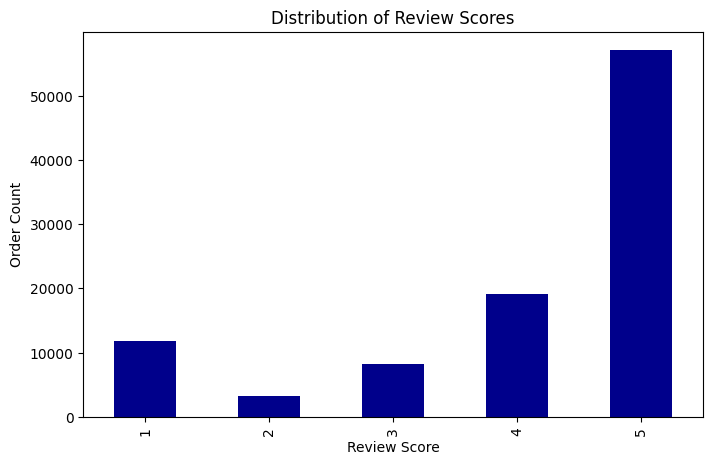

In [119]:
distribution = analysis_df["review_score"].value_counts().sort_index(ascending=True)

distribution.plot(kind="bar", color="darkblue", figsize=(8,5))
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Order Count")
plt.show()

#### Observacion

La distribución de las calificaciones muestra una clara predominancia de valoraciones positivas, siendo las cinco estrellas la categoría más frecuente. Sin embargo, la existencia de un porcentaje significativo de reseñas con una estrella evidencia que una parte de los clientes experimentó problemas durante el proceso de compra. En las siguientes secciones se analizarán variables como el tiempo de entrega, el costo de envío y el valor de las compras para determinar si existe una relación entre estos factores y las calificaciones otorgadas.

#### 2. Análisis del tiempo de entrega

El tiempo de entrega representa uno de los factores más importantes dentro del proceso de compra en una plataforma de comercio electrónico. Un retraso en la entrega puede afectar la experiencia del cliente y, en consecuencia, influir en la calificación otorgada al pedido.

En esta sección se analiza la distribución de la variable **delivery_time_days**, calculada como la diferencia entre la fecha de compra y la fecha de entrega al cliente. El objetivo es comprender el comportamiento general de los tiempos de entrega e identificar posibles valores atípicos o situaciones inusuales que puedan ser relevantes para el análisis posterior.

In [120]:
analysis_df["delivery_time_days"].describe().round(2)

count    96476.00
mean        12.09
std          9.55
min          0.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: delivery_time_days, dtype: float64

In [121]:
analysis_df[analysis_df["delivery_time_days"] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,...,unique_products,unique_sellers,payments_count,total_payment,max_installments,delivery_time_days,approval_time_hours,estimated_delivery_days,delivery_delay_days,late_delivery


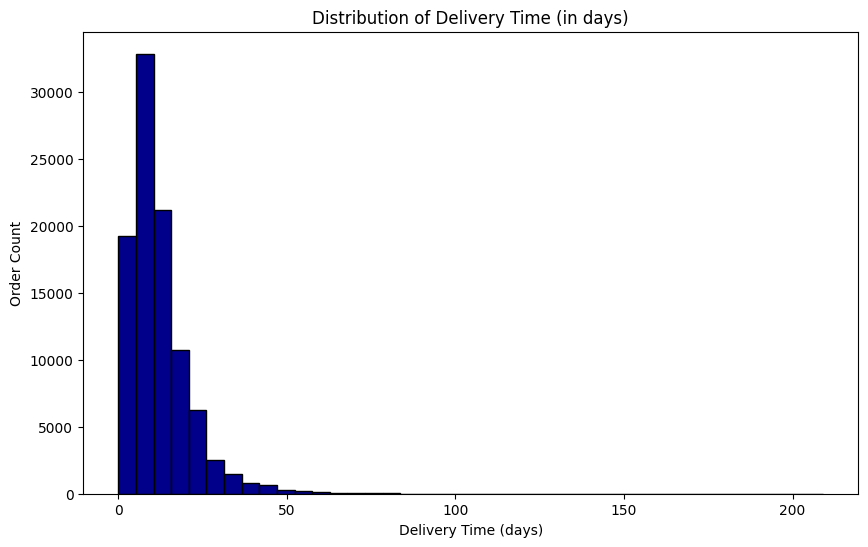

In [122]:
plt.figure(figsize=(10,6))
plt.hist(analysis_df["delivery_time_days"].dropna(), bins=40, color="darkblue", edgecolor="black")
plt.title("Distribution of Delivery Time (in days)")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Order Count")
plt.show()

La distribución del tiempo de entrega presenta una marcada asimetría positiva (sesgo hacia la derecha). La mayor concentración de pedidos se encuentra entre aproximadamente 5 y 20 días, mientras que los tiempos de entrega más largos son considerablemente menos frecuentes. La diferencia entre la media (12 días) y la mediana (10 días) indica que existen entregas excepcionalmente largas que incrementan el promedio general.

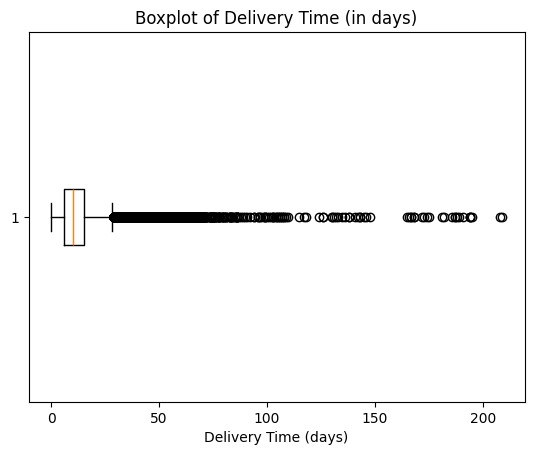

In [123]:
plt.Figure(figsize=(10,2))
plt.boxplot(analysis_df["delivery_time_days"].dropna(), vert=False)
plt.xlabel("Delivery Time (days)")
plt.title("Boxplot of Delivery Time (in days)")
plt.show()

El boxplot evidencia una alta concentración de pedidos dentro del rango intercuartílico, pero también una gran cantidad de valores atípicos (outliers) correspondientes a entregas con tiempos significativamente superiores al comportamiento habitual. Estos valores no representan necesariamente errores en los datos, sino pedidos que experimentaron demoras excepcionales.

En términos generales, el proceso logístico de Olist presenta tiempos de entrega relativamente consistentes para la mayoría de los pedidos. Sin embargo, la presencia de un grupo de órdenes con demoras considerablemente superiores al promedio plantea la necesidad de investigar si estos retrasos influyen en la satisfacción del cliente.El 50% de los pedidos fue entregado en 10 días o menos, mientras que el 75% llegó al cliente en un plazo de 15 días o menos. A pesar de este comportamiento general, se registraron casos extremos de hasta 209 días, lo que explica la presencia de numerosos valores atípicos observados en el boxplot.

### 3. Estimated Delivery Time vs. Actual Delivery Time

Después de analizar el tiempo real de entrega, resulta interesante compararlo con el tiempo estimado informado por Olist al momento de la compra.

El objetivo de esta sección es evaluar si los tiempos prometidos a los clientes reflejan el comportamiento real de las entregas. Para ello, se comparan ambas distribuciones con el fin de identificar diferencias, retrasos y posibles inconsistencias en el proceso logístico.

Esta comparación permitirá comprender si las demoras observadas corresponden a una planificación inicial o si se producen durante la ejecución de la entrega.

In [124]:
analysis_df["estimated_delivery_days"].describe().round(2)

count    99441.00
mean        23.40
std          8.83
min          1.00
25%         18.00
50%         23.00
75%         28.00
max        155.00
Name: estimated_delivery_days, dtype: float64

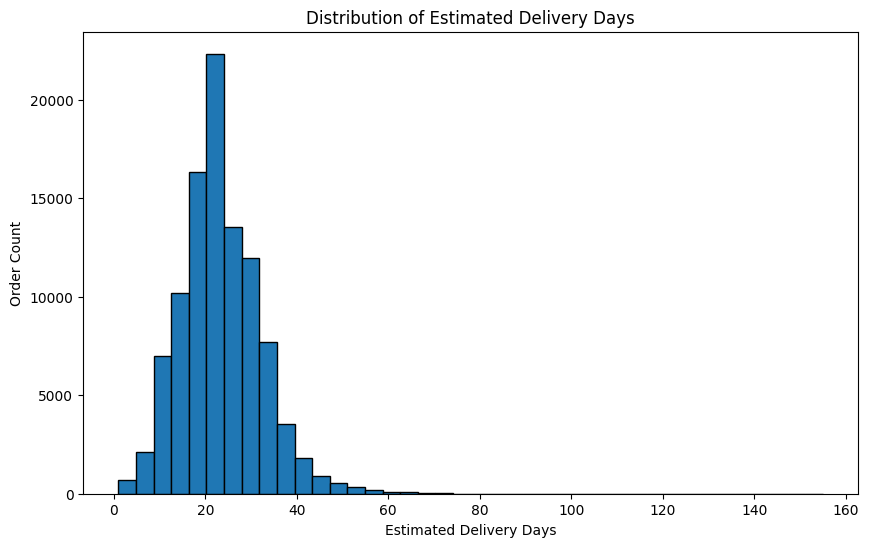

In [125]:
dispertion_estimated = analysis_df["estimated_delivery_days"]
plt.figure(figsize=(10,6))
plt.hist(dispertion_estimated, bins=40, edgecolor='black')
plt.xlabel('Estimated Delivery Days')
plt.ylabel('Order Count')
plt.title('Distribution of Estimated Delivery Days')
plt.show()

In [126]:
analysis_df["delivery_time_days"].describe().round(2)

count    96476.00
mean        12.09
std          9.55
min          0.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: delivery_time_days, dtype: float64

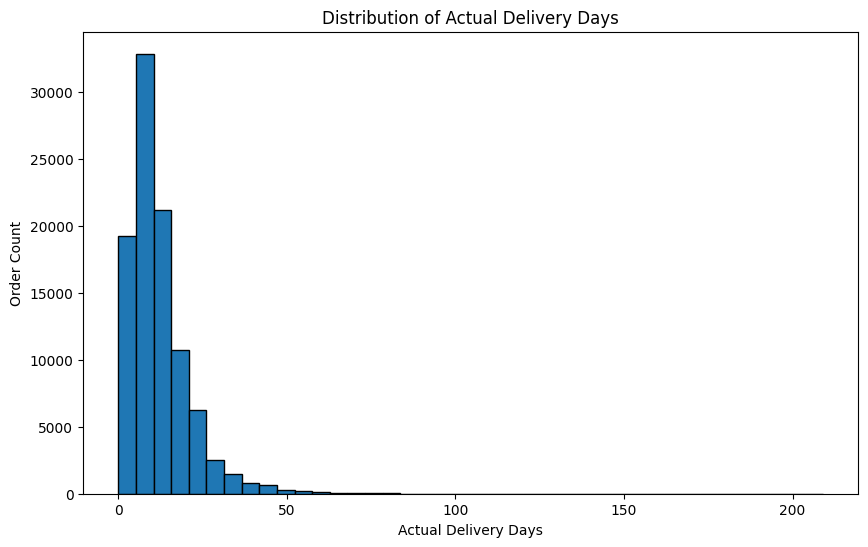

In [127]:
actual_delivery_time = analysis_df["delivery_time_days"]
plt.figure(figsize=(10,6))
plt.hist(actual_delivery_time, bins=40, edgecolor='black')
plt.xlabel('Actual Delivery Days')
plt.ylabel('Order Count')
plt.title('Distribution of Actual Delivery Days')
plt.show()

#### Creación de la variable delay_days

Aunque comparar los tiempos estimados y los tiempos reales de entrega permite observar diferencias generales entre ambas distribuciones, esta comparación no indica de forma directa si un pedido fue entregado antes o después de la fecha prometida.

Por este motivo, se crea la variable **delay_days**, calculada como la diferencia entre el tiempo real de entrega (**delivery_time_days**) y el tiempo estimado (**estimated_delivery_days**).

Esta nueva variable permite medir el desvío de cada entrega respecto al plazo informado al cliente, facilitando la identificación de pedidos adelantados, entregados en la fecha prevista o con retraso. Además, constituye una métrica clave para las siguientes etapas del análisis, donde se evaluará si las demoras en las entregas tienen un impacto sobre la satisfacción del cliente y las calificaciones otorgadas.

In [128]:
analysis_df["delay_days"] = (
    analysis_df["delivery_time_days"]
    - analysis_df["estimated_delivery_days"]
)

In [129]:
analysis_df["delay_days"].describe().round(2)

count    96476.00
mean       -11.28
std         10.19
min       -146.00
25%        -16.00
50%        -12.00
75%         -7.00
max        189.00
Name: delay_days, dtype: float64

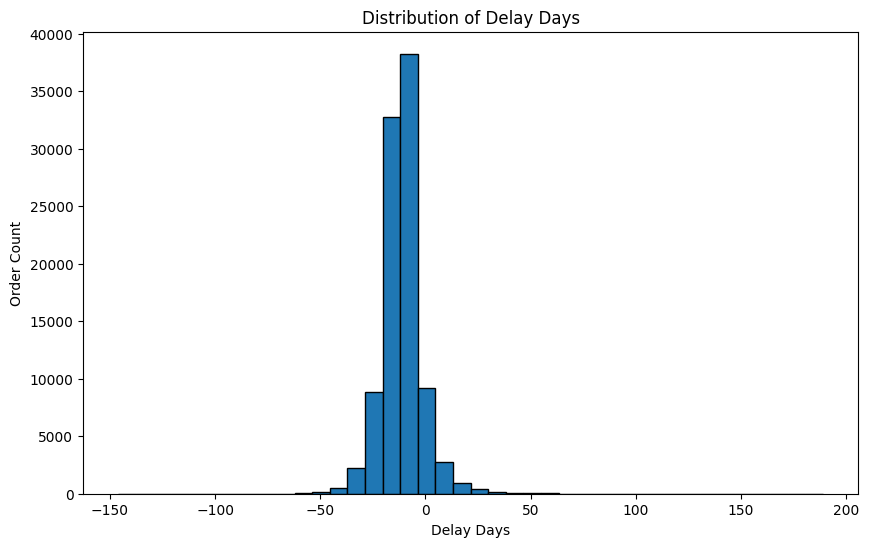

In [130]:
delay_days = analysis_df["delay_days"]
plt.figure(figsize=(10,6))
plt.hist(delay_days, bins=40, edgecolor='black')
plt.xlabel('Delay Days')
plt.title('Distribution of Delay Days')
plt.ylabel('Order Count')
plt.show()

In [131]:
retraso = (analysis_df[analysis_df["delay_days"] > 0]).shape[0]
a_tiempo = (analysis_df[analysis_df["delay_days"] == 0]).shape[0]
antes_de_tiempo = (analysis_df[analysis_df["delay_days"] < 0]).shape[0]

cantidad_total = analysis_df.shape[0]

print(f"Total de órdenes con retraso: {retraso}")
print(f"Porcentaje de órdenes con retraso: {(retraso/cantidad_total):.2%}")
print(f"Total de órdenes a tiempo: {a_tiempo}")
print(f"Porcentaje de órdenes a tiempo: {(a_tiempo/cantidad_total):.2%}")
print(f"Total de órdenes antes de tiempo: {antes_de_tiempo}")
print(f"Porcentaje de órdenes antes de tiempo: {(antes_de_tiempo/cantidad_total):.2%}")

Total de órdenes con retraso: 7308
Porcentaje de órdenes con retraso: 7.35%
Total de órdenes a tiempo: 1380
Porcentaje de órdenes a tiempo: 1.39%
Total de órdenes antes de tiempo: 87788
Porcentaje de órdenes antes de tiempo: 88.28%


**Interpretación de delay_days:**

- **Valor negativo:** el pedido fue entregado antes de la fecha estimada.
- **Valor igual a 0:** el pedido fue entregado exactamente en el plazo previsto.
- **Valor positivo:** el pedido fue entregado con retraso respecto a la fecha estimada.

La comparación entre los tiempos estimados y los tiempos reales muestra que, si bien la mayoría de las entregas se realiza dentro de los plazos esperados, existen casos donde el tiempo real supera ampliamente al tiempo originalmente prometido. Estas diferencias sugieren la presencia de retrasos logísticos que podrían influir en la experiencia del cliente

## 4. Análisis del valor de compra

El valor de una compra es una de las variables que puede influir en las expectativas y la percepción del cliente sobre el servicio recibido. Compras de mayor importe podrían generar un mayor nivel de exigencia, mientras que las de menor valor podrían presentar un comportamiento diferente en cuanto a la satisfacción del cliente.

En esta sección se analiza la distribución del valor total de cada pedido (**total_price**) con el objetivo de comprender cómo se distribuyen los montos de compra dentro de la plataforma Olist, identificar posibles valores atípicos y conocer si existen diferencias significativas entre la mayoría de las órdenes y un pequeño grupo de compras de alto valor.

Este análisis servirá como base para evaluar, en etapas posteriores, si el valor económico de una compra tiene alguna relación con las calificaciones otorgadas por los clientes.

In [132]:
analysis_df["total_price"].describe().round(2)

count    98666.00
mean       137.75
std        210.65
min          0.85
25%         45.90
50%         86.90
75%        149.90
max      13440.00
Name: total_price, dtype: float64

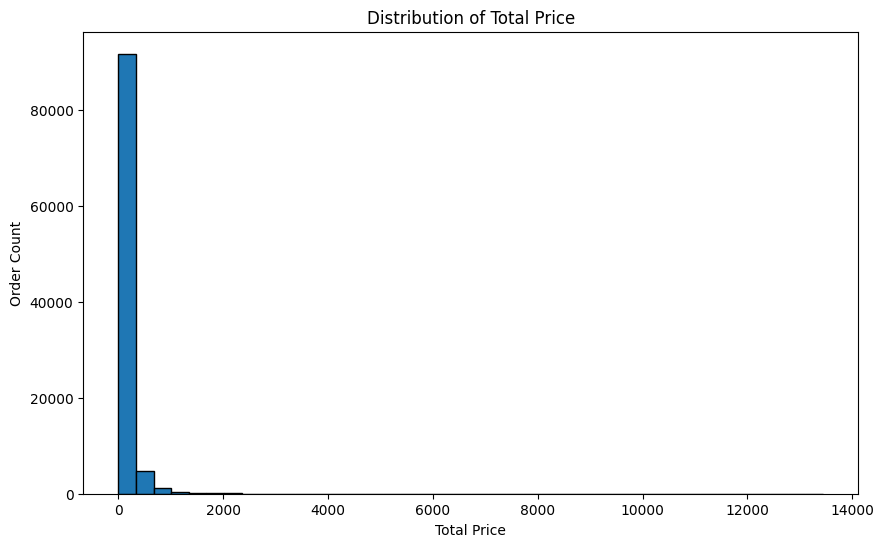

In [133]:
precio = analysis_df["total_price"]
plt.figure(figsize=(10,6))
plt.hist(precio, bins=40, edgecolor='black')
plt.xlabel('Total Price')
plt.ylabel('Order Count')
plt.title('Distribution of Total Price')
plt.show()

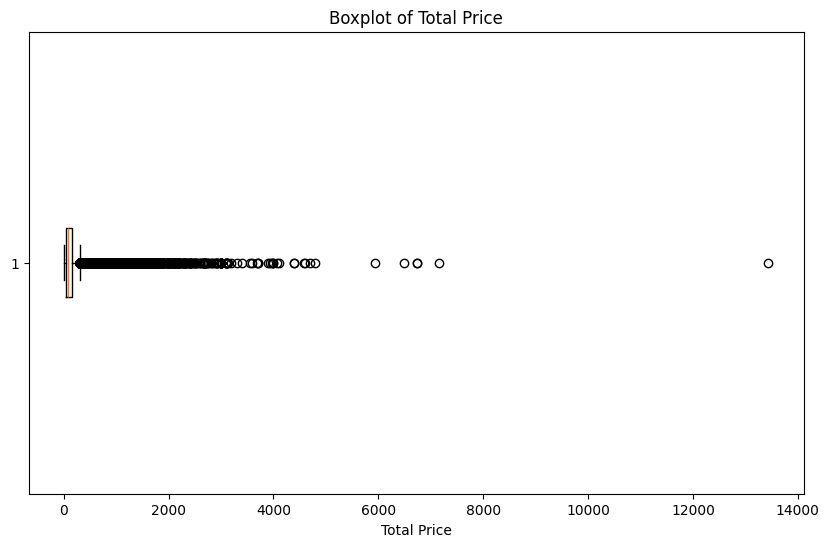

In [134]:
plt.figure(figsize=(10,6))
plt.boxplot(analysis_df["total_price"].dropna(), vert=False)
plt.xlabel("Total Price")
plt.title("Boxplot of Total Price")
plt.show()

El análisis del valor de las compras muestra que la mayoría de las órdenes se concentra en un rango de precios relativamente bajo, mientras que un número reducido de pedidos presenta importes considerablemente superiores

### 6. Freight Value Analisis

El costo de envío constituye un aspecto importante dentro de la experiencia de compra en una plataforma de comercio electrónico. Un costo de envío elevado puede afectar la percepción del cliente sobre el valor total de la compra e incluso influir en el nivel de satisfacción expresado mediante la calificación del pedido.

En esta sección se analiza la distribución de la variable **total_freight**, que representa el costo total de envío asociado a cada orden. El objetivo es conocer cómo se distribuyen estos costos, identificar posibles valores atípicos y comprender el comportamiento general de esta variable antes de estudiar su relación con las calificaciones de los clientes.

In [135]:
analysis_df["total_freight"].describe().round(2)

count    98666.00
mean        22.82
std         21.65
min          0.00
25%         13.85
50%         17.17
75%         24.04
max       1794.96
Name: total_freight, dtype: float64

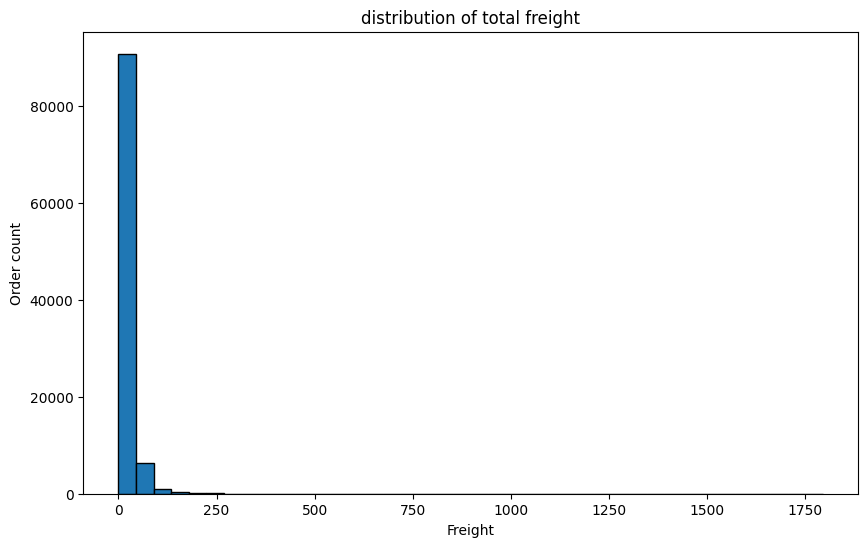

In [136]:
plt.figure(figsize=(10,6))
plt.hist(analysis_df["total_freight"], bins=40, edgecolor="black")
plt.title("distribution of total freight") 
plt.xlabel("Freight")
plt.ylabel("Order count")
plt.show()

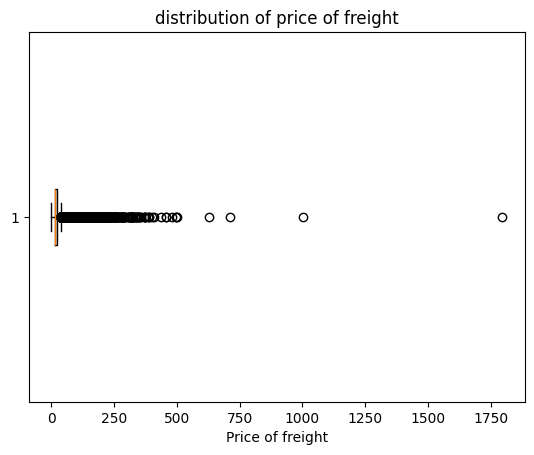

In [137]:
plt.Figure(figsize=(10,6))
plt.boxplot(analysis_df["total_freight"].dropna(), vert=False )
plt.xlabel("Price of freight")
plt.title("distribution of price of freight")
plt.show()

#### Observacion

El análisis muestra que la mayoría de los pedidos presentan costos de envío moderados, mientras que un pequeño grupo registra valores considerablemente más altos.

### 7. Numero de Items per Order

Además del valor económico de una compra, la cantidad de productos incluidos en un pedido puede influir en la complejidad del proceso logístico. Órdenes con múltiples productos pueden requerir una preparación más extensa o involucrar distintos vendedores, lo que podría afectar los tiempos de entrega y, en consecuencia, la experiencia del cliente.

En esta sección se analiza la variable **total_items**, que representa la cantidad de productos incluidos en cada orden. El objetivo es conocer el comportamiento general de las compras realizadas en la plataforma e identificar si predominan los pedidos de un único producto o las órdenes con múltiples artículos.

In [138]:
analysis_df["total_items"].describe().round(2)

count    98666.00
mean         1.14
std          0.54
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         21.00
Name: total_items, dtype: float64

In [139]:
analysis_df["total_items"].value_counts()

total_items
1.0     88863
2.0      7516
3.0      1322
4.0       505
5.0       204
6.0       198
7.0        22
8.0         8
10.0        8
12.0        5
11.0        4
9.0         3
14.0        2
15.0        2
20.0        2
13.0        1
21.0        1
Name: count, dtype: int64

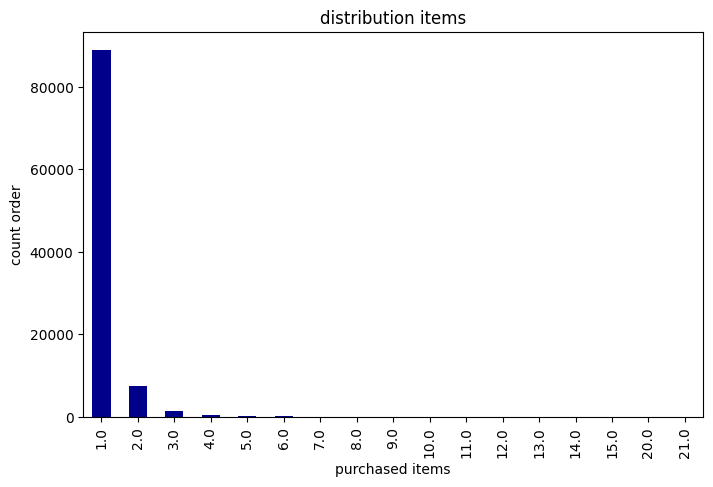

In [140]:
count_item = analysis_df["total_items"].value_counts().sort_index()
count_item.plot(kind="bar", color="darkblue", figsize=(8,5))
plt.title("distribution items")
plt.xlabel("purchased items")
plt.ylabel("count order")
plt.show()

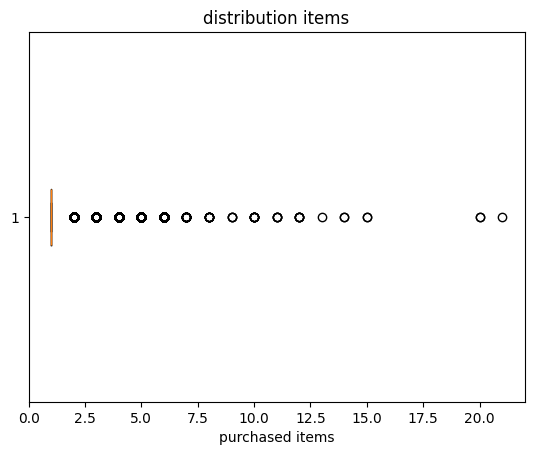

In [141]:
plt.Figure(figsize=(5,2))
plt.boxplot(analysis_df["total_items"].dropna(), vert=False)
plt.title("distribution items" )
plt.xlabel("purchased items")
plt.show()

#### Observaciones

El análisis de la cantidad de productos por orden muestra que el comportamiento predominante en la plataforma corresponde a compras de un único artículo, representando aproximadamente el 90% de los pedidos. Las órdenes con múltiples productos son considerablemente menos frecuentes y, aunque aparecen como valores atípicos en el boxplot debido a la concentración de datos en valores bajos, forman parte del comportamiento esperado del negocio. Este resultado sugiere que la mayoría de las operaciones realizadas en Olist son compras simples, mientras que los pedidos con varios productos constituyen casos particulares

## 8. Numero de Payments per Order

Además de la cantidad de productos, resulta de interés analizar la cantidad de pagos registrados por cada orden. En el dataset de Olist, una compra puede ser abonada mediante uno o varios pagos, ya sea por el uso de diferentes métodos de pago o por la división del importe total en múltiples transacciones.

En esta sección se analiza la variable **payments_count**, que representa la cantidad de pagos asociados a cada pedido. El objetivo es comprender cómo se distribuyen estos pagos dentro del conjunto de datos e identificar si predominan las órdenes con un único pago o aquellas que requieren múltiples transacciones.

In [142]:
analysis_df["payments_count"].describe()

count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
Name: payments_count, dtype: float64

In [143]:
analysis_df["payments_count"].value_counts().sort_index()

payments_count
1.0     96479
2.0      2382
3.0       301
4.0       108
5.0        52
6.0        36
7.0        28
8.0        11
9.0         9
10.0        5
11.0        8
12.0        8
13.0        3
14.0        2
15.0        2
19.0        2
21.0        1
22.0        1
26.0        1
29.0        1
Name: count, dtype: int64

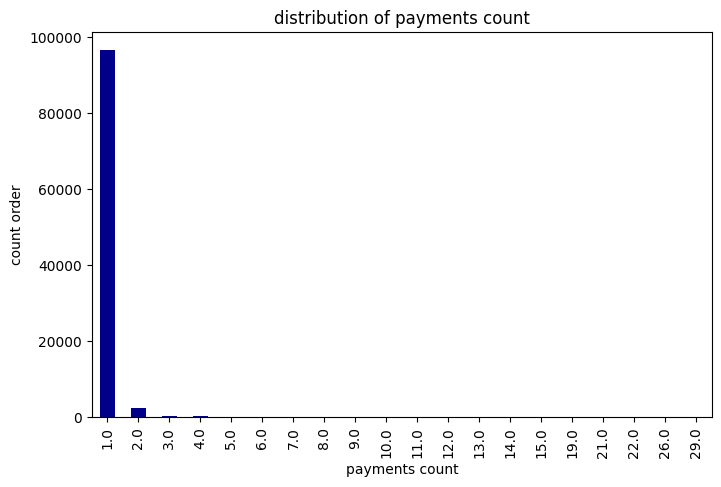

In [144]:
count_payments = analysis_df["payments_count"].value_counts().sort_index()
count_payments.plot(kind="bar", color="darkblue", figsize=(8,5))
plt.title("distribution of payments count")
plt.xlabel("payments count")
plt.ylabel("count order")
plt.show()

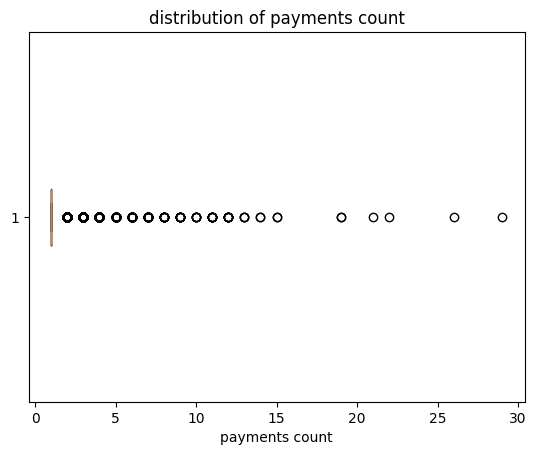

In [145]:
plt.Figure(figsize=(5,2))
plt.boxplot(analysis_df["payments_count"].dropna(), vert=False)
plt.title("distribution of payments count" )
plt.xlabel("payments count")
plt.show()

#### Observaciones 

El análisis de la cantidad de pagos por orden evidencia que la mayoría de las compras realizadas en Olist se abonan mediante una única transacción. Los pedidos con múltiples pagos representan una proporción reducida del conjunto de datos y responden a situaciones particulares del proceso de pago, sin indicar anomalías o problemas en la calidad de los datos. Estos resultados aportan una mejor comprensión del comportamiento de compra de los clientes

## 9. Factores que influyen en la satisfacción del cliente

Hasta este punto del análisis se estudiaron de manera individual las principales variables del conjunto de datos. Si bien este enfoque permitió comprender su comportamiento, no resulta suficiente para explicar qué factores pueden influir en la satisfacción de los clientes.

En esta etapa se analizan las relaciones entre la variable objetivo (**review_score**) y distintas variables del proceso de compra, como el tiempo de entrega, los retrasos, el valor de la compra, el costo de envío y la complejidad de la orden. El objetivo es identificar patrones que permitan comprender qué aspectos del servicio tienen un mayor impacto sobre la experiencia del cliente.

### 9.1 Relacion entre Delivery Time y Customer Review Score

El tiempo de entrega es uno de los factores que más puede influir en la experiencia de compra de un cliente dentro de una plataforma de comercio electrónico. Una entrega rápida puede generar una percepción positiva del servicio, mientras que retrasos prolongados pueden afectar el nivel de satisfacción y reflejarse en la calificación otorgada al pedido.

En esta sección se analiza la relación entre el tiempo real de entrega (**delivery_time_days**) y la variable objetivo del proyecto (**review_score**). El propósito es identificar si existen diferencias en los tiempos de entrega según la calificación recibida y evaluar si esta variable constituye un posible factor asociado a la satisfacción del cliente.

In [146]:
delivery_review = analysis_df.groupby("review_score")["delivery_time_days"].agg(["count", "mean", "median", "std"]).round(2)

delivery_review

,count,mean,median,std
review_score,,,,
1,9703,20.86,16.0,16.23
2,2993,16.24,13.0,12.59
3,8012,13.81,12.0,9.97
4,18937,11.85,10.0,8.30
5,56831,10.22,9.0,6.83


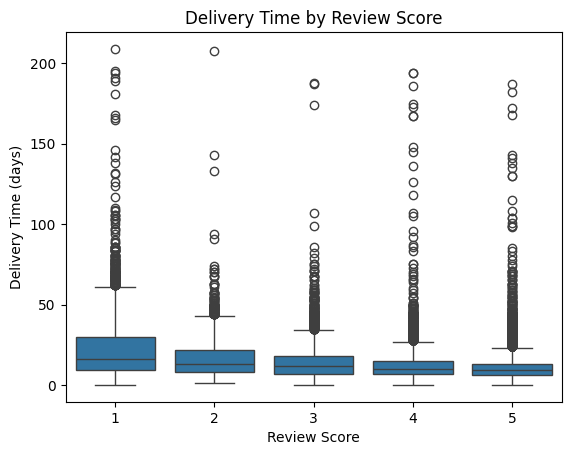

In [147]:
plt.Figure(figsize=(10,2))
sns.boxplot(data=analysis_df,x="review_score",y="delivery_time_days")
plt.title("Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Time (days)")
plt.show()

In [148]:
avg_mean = analysis_df.groupby("review_score")["delivery_time_days"].mean()
avg_mean

review_score
1    20.857261
2    16.243568
3    13.810784
4    11.846913
5    10.219722
Name: delivery_time_days, dtype: float64

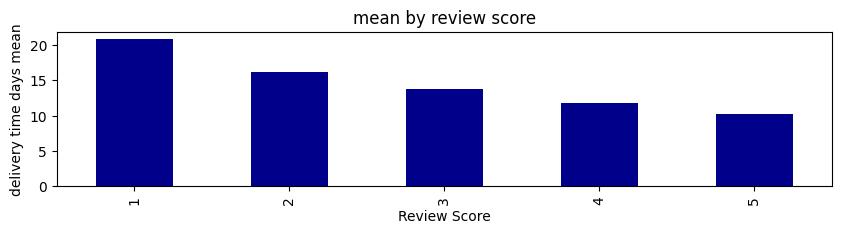

In [149]:
avg_mean.plot(kind="bar", color="darkblue",figsize=(10,2))
plt.title("mean by review score")
plt.xlabel("Review Score")
plt.ylabel("delivery time days mean")
plt.show()

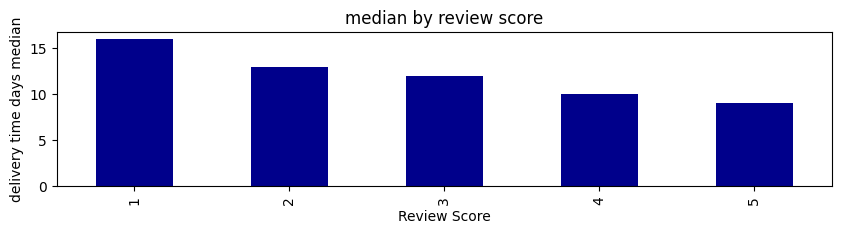

In [150]:
avg_median = analysis_df.groupby("review_score")["delivery_time_days"].median()

avg_median.plot(kind="bar",color="darkblue", figsize=(10,2))
plt.title("median by review score")
plt.xlabel("Review Score")
plt.ylabel("delivery time days median")
plt.show()


#### Conclusion de  Delivery Time y Customer Review Score

Los resultados obtenidos muestran una asociación clara entre el tiempo de entrega y las calificaciones otorgadas por los clientes. En promedio, los pedidos que recibieron mejores evaluaciones fueron entregados en menos días, mientras que las órdenes con calificaciones bajas presentaron tiempos de entrega considerablemente superiores. Aunque este análisis no permite establecer una relación causal, sí proporciona evidencia de que el tiempo de entrega podría ser un factor importante en la experiencia de compra.

### 9.2 Relacion entre Delivery Delay and Customer Review Score

Si bien el tiempo total de entrega es un aspecto importante de la experiencia del cliente, el cumplimiento del plazo prometido puede tener un impacto aún mayor sobre la percepción del servicio.

Por este motivo, en esta sección se analiza la relación entre la variable **delay_days**, que representa la diferencia entre el tiempo real y el tiempo estimado de entrega, y la calificación otorgada por los clientes (**review_score**).

El objetivo es evaluar si los pedidos entregados con retraso respecto a la fecha prometida presentan una tendencia a recibir calificaciones más bajas, permitiendo determinar si el cumplimiento de los plazos constituye un factor relevante en la satisfacción del cliente.

In [151]:
delay_review = analysis_df.groupby("review_score")["delay_days"].agg(["count", "mean", "median", "std"])

delay_review

,count,mean,median,std
review_score,,,,
1,9703,-3.441513,-7.0,16.169341
2,2993,-7.925159,-9.0,12.765617
3,8012,-10.162257,-11.0,10.436648
4,18937,-11.781380,-12.0,9.066089
5,56831,-12.785733,-13.0,8.175686


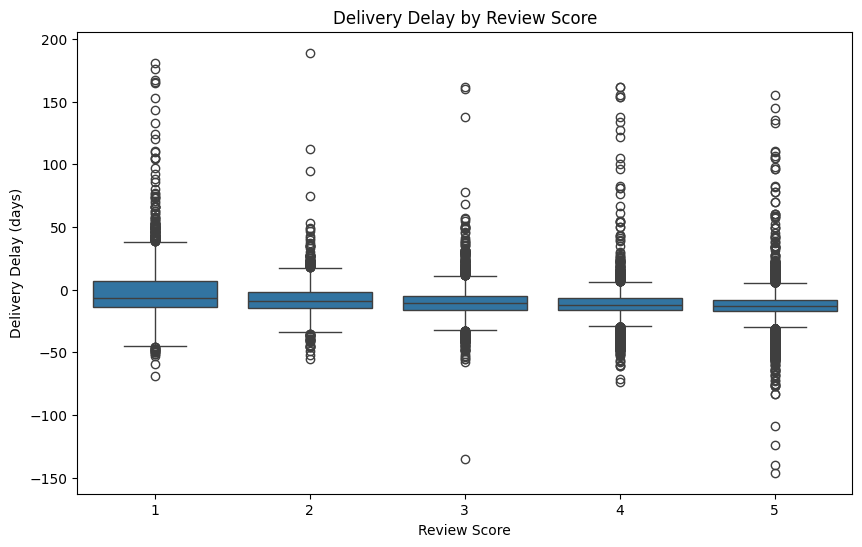

In [152]:
plt.figure(figsize=(10,6))

sns.boxplot(data=analysis_df,x="review_score",y="delay_days")

plt.title("Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Delay (days)")

plt.show()

<Axes: xlabel='review_score'>

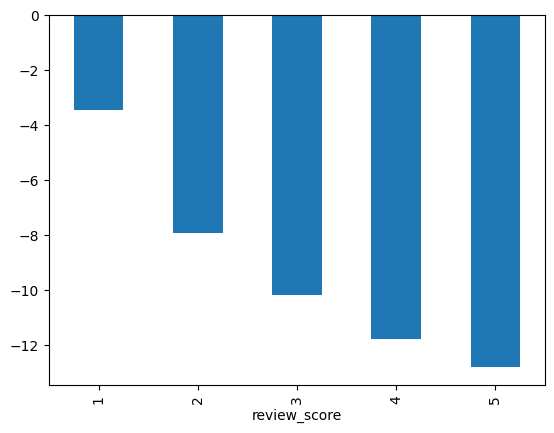

In [153]:
avg_delay = (analysis_df.groupby("review_score")["delay_days"].mean())

avg_delay.plot(kind="bar")

<Axes: xlabel='review_score'>

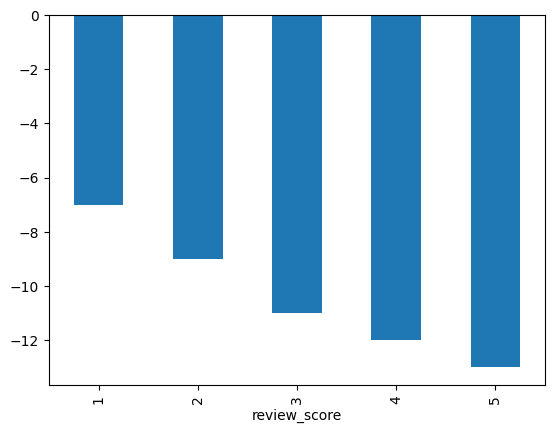

In [154]:
median_delay = (analysis_df.groupby("review_score")["delay_days"].median())

median_delay.plot(kind="bar")

In [163]:
late_percentage = (analysis_df.assign(late = analysis_df["delay_days"] > 0).groupby("review_score")["late"].mean().mul(100).round(2) )

late_percentage

review_score
1    30.60
2    18.61
3     9.91
4     4.36
5     2.54
Name: late, dtype: float64

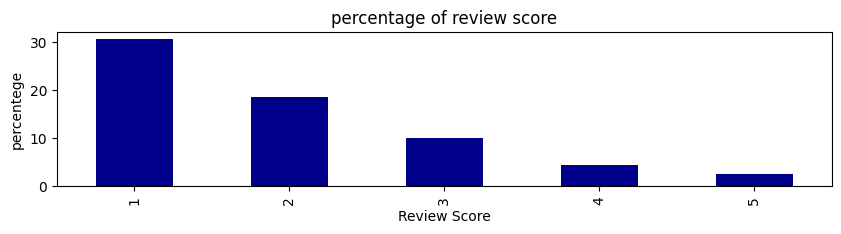

In [162]:
late_percentage.plot(kind="bar",color="darkblue",figsize=(10,2))
plt.title("percentage of review score")
plt.xlabel("Review Score")
plt.ylabel("percentege")
plt.show()

#### Conclusion de Delivery Delay y Customer Review Score

El análisis de la variable delay_days muestra que, en promedio, los pedidos fueron entregados antes de la fecha estimada, independientemente de la calificación recibida. Sin embargo, también se observa que las mejores evaluaciones corresponden a órdenes entregadas con un mayor margen de anticipación respecto al plazo prometido.

Además, al analizar exclusivamente las entregas con retraso, se identifica una diferencia significativa entre los distintos niveles de satisfacción. Mientras que cerca del 30,6% de las órdenes calificadas con una estrella fueron entregadas fuera del plazo previsto, este porcentaje desciende hasta 2,54% en las órdenes con cinco estrellas.

En conjunto, estos resultados sugieren que el cumplimiento de los plazos de entrega constituye un factor estrechamente asociado con la satisfacción del cliente. Aunque el tiempo total de entrega es importante, los datos indican que respetar —e incluso superar— las expectativas generadas al momento de la compra puede tener un impacto positivo en la percepción del servicio

### 9.3 Relacion entre Purchase Value and Customer Review Score

Además de los aspectos logísticos, el valor económico de una compra también podría influir en la percepción del cliente sobre el servicio recibido. Es posible que los clientes que realizan compras de mayor importe tengan expectativas más altas respecto a la calidad del proceso de compra, mientras que aquellos con compras de menor valor presenten un comportamiento diferente al momento de evaluar su experiencia.

En esta sección se analiza la relación entre el valor total de cada pedido (**total_price**) y la calificación otorgada por el cliente (**review_score**). El objetivo es identificar si existen diferencias significativas entre los distintos niveles de satisfacción y determinar si el importe de la compra constituye un factor asociado a las reseñas de los clientes.

In [ ]:
price_review = (analysis_df.groupby("review_score")["total_price"].agg(["count", "mean", "median", "std"]).round(2))

price_review

,count,mean,median,std
review_score,,,,
1,11243,167.15,99.00,291.78
2,3149,144.85,89.90,217.81
3,8188,127.63,82.97,167.98
4,19059,132.70,84.00,196.46
5,57027,134.71,84.99,200.53


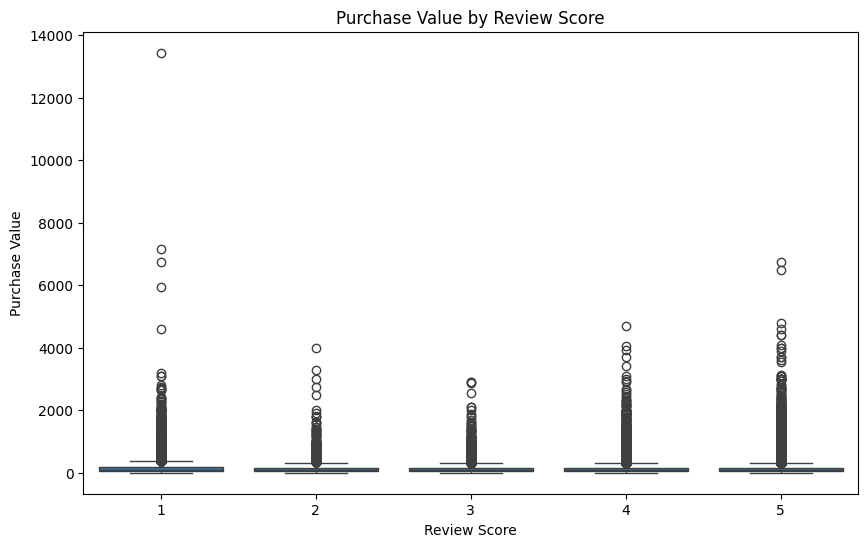

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=analysis_df,
    x="review_score",
    y="total_price"
)

plt.title("Purchase Value by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Purchase Value")

plt.show()

<Axes: xlabel='review_score'>

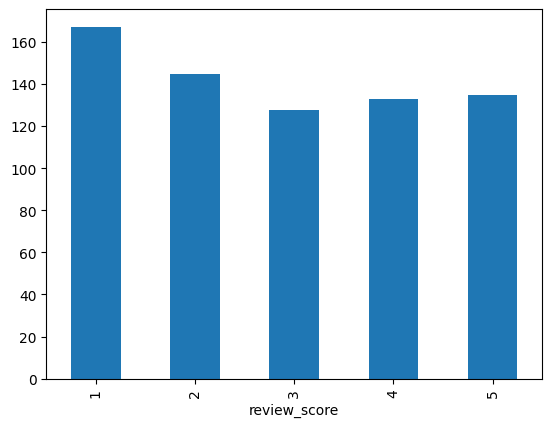

In [164]:
avg_price = (analysis_df.groupby("review_score")["total_price"].mean())

avg_price.plot(kind="bar")

<Axes: xlabel='review_score'>

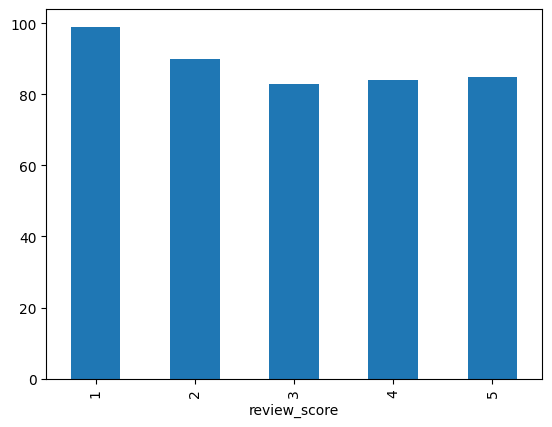

In [165]:
median_price = (analysis_df.groupby("review_score")["total_price"].median())

median_price.plot(kind="bar")

#### Conclusion Purchase Value y Customer Review Score

A diferencia de las variables relacionadas con la logística, el valor económico de la compra no muestra una asociación clara con las calificaciones otorgadas por los clientes. Aunque las órdenes con una estrella presentan, en promedio, un importe ligeramente superior, las diferencias entre el resto de las categorías son pequeñas y no permiten identificar una tendencia consistente. Estos resultados sugieren que el precio de la compra, por sí solo, no constituye un factor determinante en la satisfacción del cliente dentro del conjunto de datos analizado.

## 9.4 Relacion entre Freight Cost and Customer Review Score

Además del valor total de la compra, el costo de envío representa un componente importante de la experiencia de compra en el comercio electrónico. Un costo de envío elevado podría influir en la percepción del cliente sobre el servicio recibido, especialmente si considera que el importe pagado no se corresponde con la calidad o la rapidez de la entrega.

En esta sección se analiza la relación entre el costo total de envío (**total_freight**) y la calificación otorgada por los clientes (**review_score**). El objetivo es evaluar si existen diferencias en los costos de envío entre los distintos niveles de satisfacción e identificar si esta variable presenta una asociación con las reseñas de los clientes.

In [ ]:
freight_review = (analysis_df.groupby("review_score")["total_freight"].agg(["count", "mean", "median", "std"]).round(2))

freight_review

,count,mean,median,std
review_score,,,,
1,11243,27.74,18.44,29.90
2,3149,26.15,18.00,26.08
3,8188,23.49,17.63,22.17
4,19059,22.39,17.19,19.44
5,57027,21.72,16.79,19.84


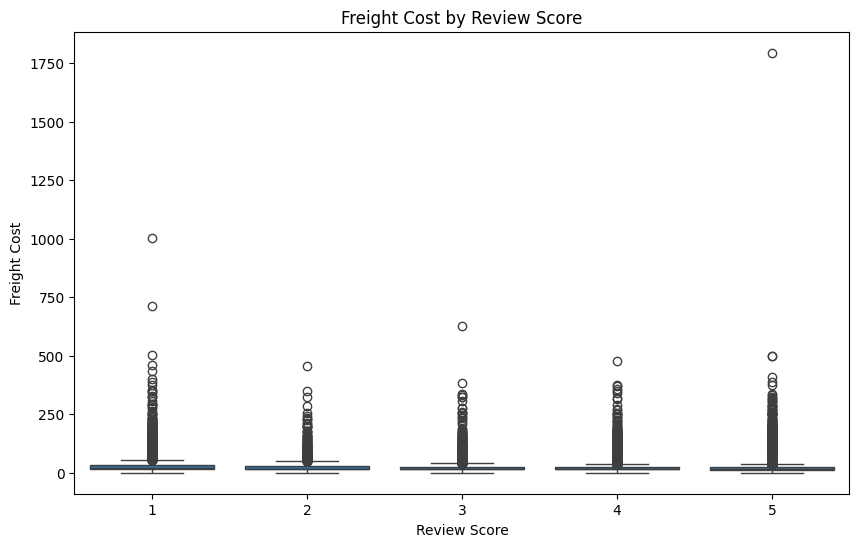

In [167]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=analysis_df,
    x="review_score",
    y="total_freight"
)

plt.title("Freight Cost by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Freight Cost")

plt.show()

<Axes: xlabel='review_score'>

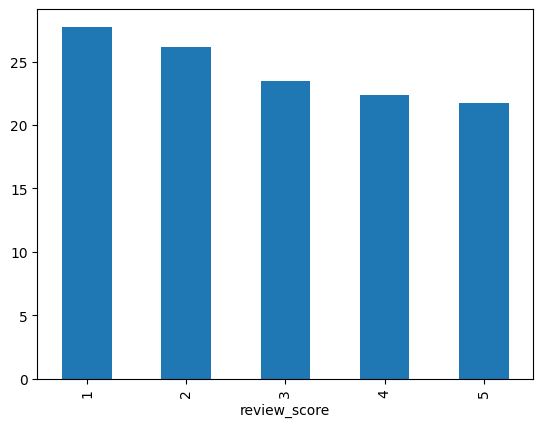

In [169]:
avg_freight = (analysis_df.groupby("review_score")["total_freight"].mean())

avg_freight.plot(kind="bar")

<Axes: xlabel='review_score'>

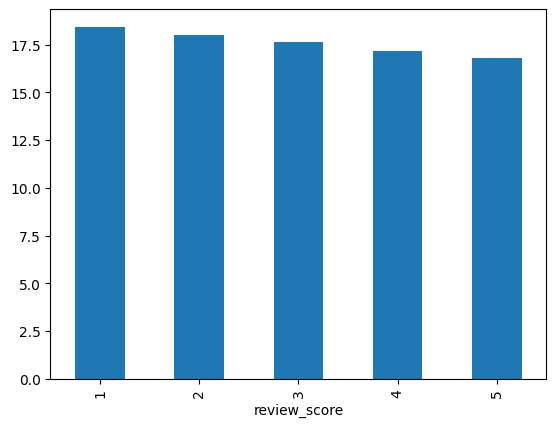

In [170]:
median_freight = (analysis_df.groupby("review_score")["total_freight"].median())

median_freight.plot(kind="bar")

#### Conclusion Freight Cost y Customer Review Score

El costo de envío presenta una asociación débil con las calificaciones de los clientes. Si bien las órdenes con menores evaluaciones registran, en promedio, costos de envío ligeramente superiores, las diferencias observadas son considerablemente menores que las identificadas en las variables relacionadas con la logística, como el tiempo de entrega y el cumplimiento del plazo estimado. Estos resultados sugieren que el costo de envío podría influir en la percepción del cliente, aunque su impacto parece ser menos relevante que el desempeño del proceso de entrega.

### 9.5 Relacion entre Number of Items and Customer Review Score

La cantidad de productos incluidos en una orden puede incrementar la complejidad del proceso de preparación y entrega. Los pedidos con múltiples artículos pueden requerir una mayor coordinación logística, especialmente cuando intervienen distintos vendedores, lo que podría influir en la experiencia del cliente y, en consecuencia, en la calificación otorgada.

En esta sección se analiza la relación entre la cantidad de productos por pedido (**total_items**) y la variable objetivo (**review_score**). El propósito es determinar si las órdenes con un mayor número de artículos presentan diferencias significativas en las evaluaciones de los clientes.

In [ ]:
items_review = (analysis_df.groupby("review_score")["total_items"].agg(["count", "mean", "median", "std"]).round(2))

items_review

,count,mean,median,std
review_score,,,,
1,11243,1.31,1.0,0.86
2,3149,1.25,1.0,0.67
3,8188,1.16,1.0,0.57
4,19059,1.12,1.0,0.48
5,57027,1.11,1.0,0.45


<Axes: xlabel='review_score'>

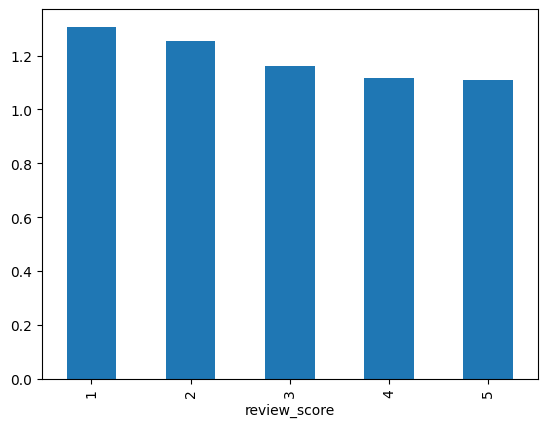

In [ ]:
avg_items = (analysis_df.groupby("review_score")["total_items"].mean())

avg_items.plot(kind="bar")

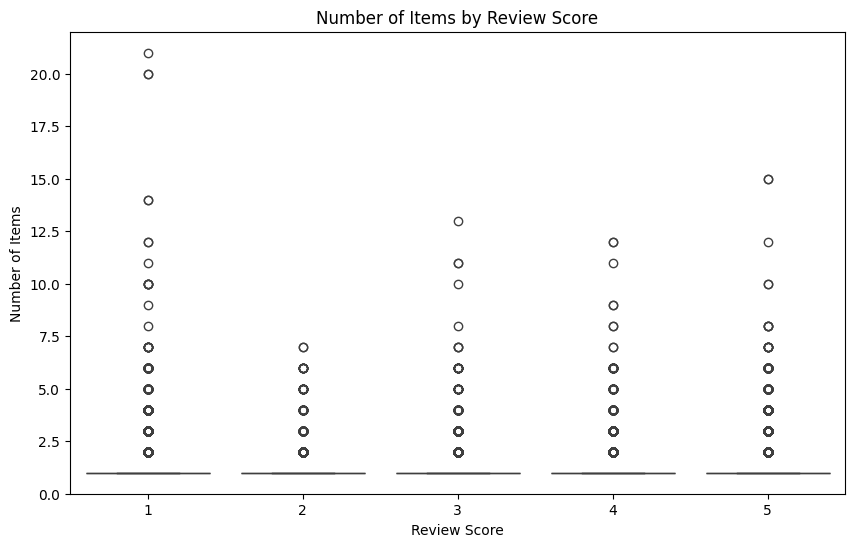

In [173]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=analysis_df,
    x="review_score",
    y="total_items"
)

plt.title("Number of Items by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Number of Items")

plt.show()

#### Conclusion Number of Items y Customer Review Score

La cantidad de productos por orden no presenta una asociación significativa con las calificaciones otorgadas por los clientes. Aunque las órdenes con una estrella muestran, en promedio, un número ligeramente superior de artículos, las diferencias respecto al resto de las categorías son pequeñas y no evidencian un patrón suficientemente marcado como para considerar esta variable un factor determinante de la satisfacción del cliente. En comparación con las variables logísticas analizadas previamente, el número de productos parece tener una influencia considerablemente menor sobre la experiencia de compra.

### 9.6 Relacion entre Number of Payments and Customer Review Score

La cantidad de pagos asociados a una orden representa otra característica que podría influir en la experiencia de compra. En algunos casos, un pedido puede abonarse mediante múltiples transacciones, ya sea por la utilización de distintos métodos de pago o por la división del importe total en varias cuotas.

En esta sección se analiza la relación entre la cantidad de pagos registrados por orden (**payments_count**) y la calificación otorgada por los clientes (**review_score**). El objetivo es evaluar si las órdenes con un mayor número de pagos presentan diferencias en los niveles de satisfacción o si esta variable tiene una influencia limitada sobre las reseñas.

In [174]:
payments_review = (
    analysis_df
    .groupby("review_score")["payments_count"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

payments_review

,count,mean,median,std
review_score,,,,
1,11796,1.05,1.0,0.45
2,3213,1.06,1.0,0.42
3,8241,1.04,1.0,0.32
4,19092,1.04,1.0,0.36
5,57098,1.04,1.0,0.38


<Axes: xlabel='review_score'>

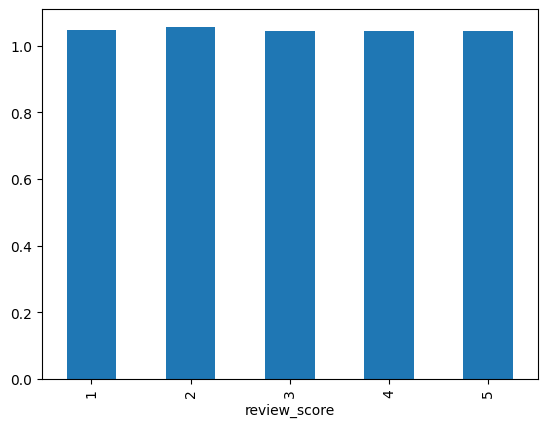

In [175]:
avg_payments = (
    analysis_df
    .groupby("review_score")["payments_count"]
    .mean()
)

avg_payments.plot(kind="bar")

<Axes: xlabel='review_score'>

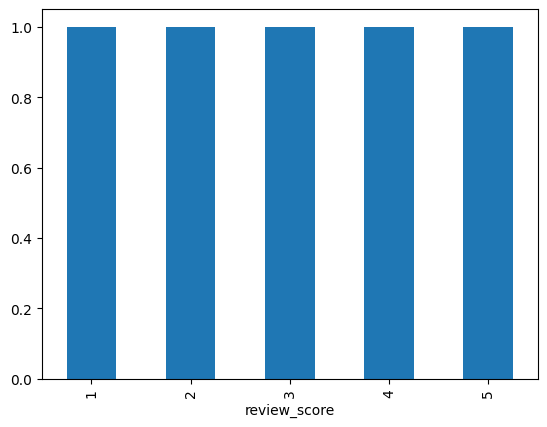

In [176]:
median_payments = (
    analysis_df
    .groupby("review_score")["payments_count"]
    .median()
)

median_payments.plot(kind="bar")

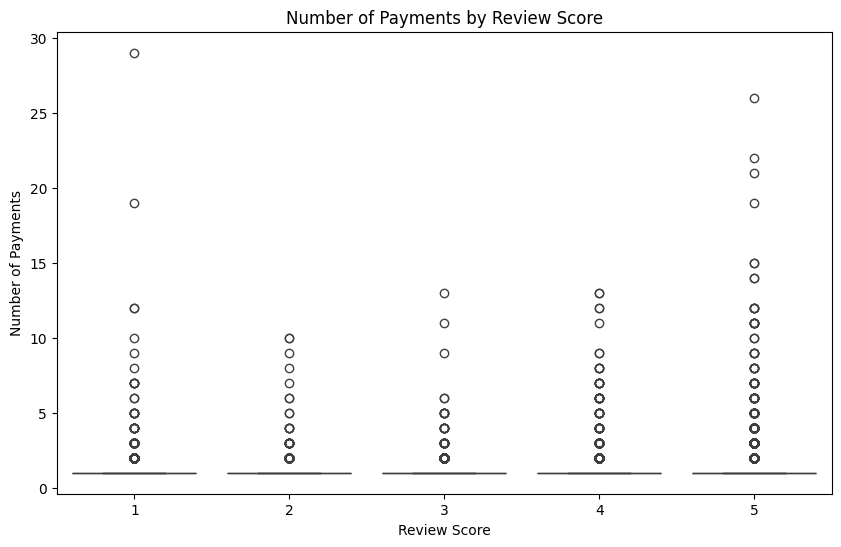

In [177]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=analysis_df,
    x="review_score",
    y="payments_count"
)

plt.title("Number of Payments by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Number of Payments")

plt.show()

#### Conclusion Number of Payments y Customer Review Score

La cantidad de pagos registrados por orden no muestra una asociación significativa con las calificaciones otorgadas por los clientes. Las diferencias entre los distintos niveles de review_score son prácticamente inexistentes y no permiten identificar un patrón que vincule esta variable con la experiencia de compra. En consecuencia, dentro del conjunto de datos analizado, la complejidad del proceso de pago no parece constituir un factor determinante para explicar la satisfacción del cliente.

## 9.7 Resumen de los hallazgos claves

El análisis relacional permitió evaluar la asociación entre la variable objetivo (**review_score**) y distintos factores relacionados con el proceso de compra. Los resultados muestran que las variables vinculadas a la logística presentan una relación considerablemente más fuerte con la satisfacción del cliente que aquellas relacionadas con el valor económico o la complejidad de la orden.

En particular, el tiempo de entrega y el cumplimiento del plazo estimado evidencian una tendencia clara: las órdenes entregadas en menos tiempo y con mayor anticipación respecto a la fecha prometida tienden a recibir mejores calificaciones. En contraste, variables como el valor de la compra, el costo de envío, la cantidad de productos y el número de pagos muestran diferencias reducidas entre las distintas categorías de **review_score**, lo que sugiere una influencia limitada sobre la percepción del cliente.

| Variable Analizada     | Hallazgo Principal                                                              | Asociación con **review_score** |
| ---------------------- | ------------------------------------------------------------------------------- | ----------------------------- |
| **Delivery Time**      | Menor tiempo de entrega → mejores calificaciones.                               | **Alta**                      |
| **Delivery Delay**     | Cumplir o superar el plazo prometido se asocia con mejores reseñas.             | **Muy alta**                  |
| **Purchase Value**     | No se observó una tendencia consistente.                                        | **Baja**                      |
| **Freight Cost**       | Los costos más altos presentan una ligera asociación con peores calificaciones. | **Baja**                      |
| **Number of Items**    | Las diferencias entre grupos son mínimas.                                       | **Muy baja**                  |
| **Number of Payments** | No se identificó una relación relevante.                                        | **muy baja**           |


In [178]:
analysis_df.to_csv(
    "../data/processed/analysis_dataset.csv",
    index=False
)

## 10. Perspectivas empresariales

El análisis exploratorio permitió identificar distintos factores asociados con la satisfacción del cliente dentro de la plataforma Olist. Sin embargo, más allá de describir los datos, resulta importante interpretar estos resultados desde una perspectiva de negocio.

En esta sección se presentan los principales hallazgos obtenidos durante el análisis y las posibles implicancias que podrían tener para la gestión logística y la experiencia del cliente.

### El desempeño en la entrega es el principal factor determinante de la satisfacción del cliente.

Los análisis mostraron que las variables relacionadas con el proceso de entrega presentan la asociación más fuerte con las calificaciones de los clientes. Tanto el tiempo total de entrega como el cumplimiento del plazo estimado evidencian una relación consistente con el nivel de satisfacción.

Las órdenes entregadas en menos tiempo y con mayor anticipación respecto a la fecha prometida tienden a recibir mejores evaluaciones, mientras que los retrasos se concentran con mayor frecuencia en las reseñas negativas.

Estos resultados sugieren que optimizar el desempeño logístico representa una de las oportunidades más importantes para mejorar la experiencia del cliente.

### Las variables económicas tienen una influencia limitada.

A diferencia de las variables logísticas, el valor económico de la compra y el costo de envío presentan asociaciones considerablemente más débiles con las calificaciones de los clientes.

Si bien las órdenes con menores evaluaciones registran, en promedio, costos de envío ligeramente superiores, las diferencias observadas son reducidas y no permiten concluir que estas variables sean factores determinantes de la satisfacción.

Esto indica que, dentro del conjunto de datos analizado, la percepción del servicio parece estar más influenciada por la calidad del proceso de entrega que por el importe económico de la compra.

### La complejidad del pedido no afecta significativamente la satisfacción del cliente.

Las variables relacionadas con la complejidad de las órdenes, como la cantidad de productos y el número de pagos registrados por compra, no muestran diferencias relevantes entre los distintos niveles de satisfacción.

Los resultados indican que estas características mantienen un comportamiento muy similar independientemente de la calificación otorgada por el cliente, por lo que su influencia sobre la experiencia de compra parece ser limitada.

| Hallazgo                                                       | Evidencia                                                                            |
| -------------------------------------------------------------- | ------------------------------------------------------------------------------------ |
| La logística es el principal factor asociado a la satisfacción | Tiempo de entrega y retrasos muestran la asociación más fuerte.                      |
| Cumplir el plazo prometido mejora la percepción del servicio   | Los pedidos con retraso concentran una mayor proporción de reseñas negativas.        |
| El valor económico tiene poca influencia                       | Precio y costo de envío presentan diferencias reducidas entre las calificaciones.    |
| La complejidad de la orden no explica las reseñas              | La cantidad de productos y de pagos prácticamente no varían según el `review_score`. |







## 11. Conclusiones Finales

El objetivo de este proyecto fue analizar los factores asociados a la satisfacción de los clientes utilizando el Brazilian E-Commerce Public Dataset by Olist. Para ello, se desarrolló un proceso completo de análisis de datos que incluyó la integración de múltiples fuentes de información, la evaluación y limpieza de los datos, la creación de nuevas variables y un análisis exploratorio orientado a identificar relaciones entre las características de las órdenes y las calificaciones otorgadas por los clientes.

Los resultados obtenidos permitieron responder la pregunta de investigación planteada al inicio del proyecto y extraer conclusiones respaldadas por la evidencia encontrada durante el análisis.

### Objetivos alcanzados

A lo largo del proyecto se integraron diferentes tablas del dataset para construir una base analítica que reuniera información sobre clientes, pedidos, pagos, productos, costos de envío y reseñas.

Posteriormente, se realizaron tareas de limpieza y preparación de datos, incluyendo el tratamiento de valores faltantes, la validación de registros y la creación de variables derivadas, como el tiempo real de entrega y la diferencia entre la fecha estimada y la fecha efectiva de entrega.

Finalmente, el análisis exploratorio permitió evaluar la relación entre distintas variables y la satisfacción del cliente, identificando cuáles presentan una asociación más clara con las calificaciones registradas.

### conclusiones

Los resultados muestran que las variables relacionadas con el proceso logístico presentan la asociación más fuerte con la satisfacción del cliente. En particular, el tiempo total de entrega y el cumplimiento del plazo estimado fueron los factores que evidenciaron las diferencias más claras entre las distintas categorías de calificación.

En contraste, variables como el valor total de la compra, el costo de envío, la cantidad de productos por orden y el número de pagos mostraron asociaciones débiles o prácticamente inexistentes con las reseñas de los clientes. Esto sugiere que, dentro del conjunto de datos analizado, la experiencia de entrega tiene un mayor impacto sobre la percepción del servicio que las características económicas o la complejidad de la compra.

### Recomendaciones 

A partir de los resultados obtenidos, pueden plantearse algunas recomendaciones orientadas a mejorar la satisfacción de los clientes:

- Priorizar acciones destinadas a reducir los tiempos de entrega y minimizar los retrasos respecto a la fecha prometida.
- Mejorar la precisión de las estimaciones de entrega para gestionar adecuadamente las expectativas de los clientes.
- Monitorear de forma continua indicadores logísticos relacionados con los tiempos de entrega y el porcentaje de órdenes entregadas fuera del plazo previsto.
- Complementar este análisis con información adicional sobre calidad de los productos, atención al cliente y devoluciones, ya que estos factores también podrían influir en las calificaciones y no se encuentran representados en el dataset utilizado.


Este proyecto permitió desarrollar un flujo completo de análisis de datos, desde la integración y preparación de múltiples fuentes hasta la exploración de relaciones entre variables y la obtención de conclusiones orientadas al negocio. A través del uso de Python, Pandas, NumPy, Matplotlib y Seaborn, se construyó una base analítica sólida que permitió transformar datos en información útil para apoyar la toma de decisiones.